# S2_Validación — Evaluación Sumativa 2

**MCDI501: Estadística Computacional para la Toma de Decisiones**
**Fase 3: Simulación, remuestreo y análisis de sensibilidad**
**Proyecto:** Análisis estadístico de condiciones meteorológicas en Australia
**Dataset:** WeatherAUS / Rain in Australia
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza
**Docente:** Dr. Jean Paul Maidana González
**Repositorio:** https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2

## Propósito del notebook

Este cuaderno corresponde a la **Evaluación Sumativa 2 (Fase 3)** y se construye **explícitamente sobre los resultados de la Sumativa 1** (parámetros estimados, intervalos de confianza, pruebas de hipótesis y correlaciones). El objetivo es demostrar, con evidencia computacional, la **robustez** de esas estimaciones y la **sensibilidad** de las conclusiones frente a cambios en los datos o en los supuestos, mediante:

1. Validación bootstrap (percentil y BCa) de los intervalos de confianza de S1.
2. Validación por permutación de las pruebas de hipótesis de S1.
3. Evaluación de estabilidad de correlaciones mediante bootstrap.
4. Simulación Monte Carlo basada en parámetros de S1, con análisis de convergencia.
5. Análisis de robustez frente a outliers y supuestos (jackknife, remuestreo, trimmed mean).
6. Síntesis de resultados validados como insumo directo para la Sumativa 3.

Todo el procedimiento es reproducible: se fija una semilla (`SEED = 42`, la misma de S1) y cada bloque de remuestreo/simulación usa un `numpy.random.default_rng` derivado de esa semilla.


## 0. Configuración inicial y reproducibilidad

Se cargan las librerías, se fija la semilla y se reconstruyen —a partir del dataset original— los mismos objetos de trabajo utilizados en S1 (`df`, variables binarias auxiliares), de modo que este notebook pueda ejecutarse de forma independiente y, a la vez, quede explícitamente anclado a los resultados previos.

In [1]:
# Librerías base
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
print(f"Semilla fijada: {SEED}")


Semilla fijada: 42


In [2]:
# Carga reproducible del dataset (misma lógica que S1)
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
candidate_paths = []
for root in candidate_roots:
    candidate_paths.extend([
        root / "data" / "raw" / "weatherAUS.csv",
        root / "weatherAUS.csv",
    ])

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró weatherAUS.csv. Debe ubicarse en data/raw/weatherAUS.csv "
        "respecto de la raíz del repositorio."
    )

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["RainToday_bin"] = df["RainToday"].map({"No": 0, "Yes": 1})
df["RainTomorrow_bin"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

FIG_DIR = PROJECT_ROOT / "results" / "figures_s2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print("Figuras de S2 se guardarán en: results/figures_s2")


Dataset: 145,460 filas x 25 columnas
Figuras de S2 se guardarán en: results/figures_s2


## 1. Resultados de referencia de la Sumativa 1

Antes de validar, se recalculan explícitamente los resultados de S1 que sirven de línea base para todo el trabajo de esta fase: los intervalos de confianza clásicos (t de Student y Wilson), las pruebas de hipótesis (Welch + d de Cohen) y las correlaciones con `RainTomorrow_bin`. Esto asegura trazabilidad total entre S1 y S2.

In [3]:
import math

def t_confidence_interval_mean(series, confidence=0.95):
    x = series.dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / math.sqrt(n)
    alpha = 1 - confidence
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = tcrit * se
    return {"n": n, "estimación": mean, "desv_est": sd, "error_estándar": se,
            "IC95_inf": mean - margin, "IC95_sup": mean + margin, "método": "t de Student"}

def wilson_interval(successes, n, confidence=0.95):
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha/2)
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    half_width = z * math.sqrt((phat*(1-phat)/n) + (z**2/(4*n**2))) / denom
    return center - half_width, center + half_width

estimate_vars = ["MaxTemp", "Humidity3pm", "WindGustSpeed"]
ci_rows_s1 = []
for var in estimate_vars:
    res = t_confidence_interval_mean(df[var])
    ci_rows_s1.append({"parámetro": f"Media de {var}", **res})

rain_valid = df["RainTomorrow"].dropna()
n_rain = len(rain_valid)
success_rain = int((rain_valid == "Yes").sum())
phat_rain = success_rain / n_rain
wilson_inf, wilson_sup = wilson_interval(success_rain, n_rain)
ci_rows_s1.append({"parámetro": "Proporción RainTomorrow = Yes", "n": n_rain,
                    "estimación": phat_rain, "desv_est": np.nan, "error_estándar": np.nan,
                    "IC95_inf": wilson_inf, "IC95_sup": wilson_sup, "método": "Wilson"})

ci_s1 = pd.DataFrame(ci_rows_s1)
ci_s1_display = ci_s1.copy()
for c in ["estimación", "desv_est", "error_estándar", "IC95_inf", "IC95_sup"]:
    ci_s1_display[c] = ci_s1_display[c].astype(float).round(4)
print("Intervalos de confianza clásicos de S1 (línea base):")
ci_s1_display


Intervalos de confianza clásicos de S1 (línea base):


,parámetro,n,estimación,desv_est,error_estándar,IC95_inf,IC95_sup,método
0,Media de MaxTemp,144199,23.2213,7.1190,0.0187,23.1846,23.2581,t de Student
1,Media de Humidity3pm,140953,51.5391,20.7959,0.0554,51.4306,51.6477,t de Student
2,Media de WindGustSpeed,135197,40.0352,13.6071,0.0370,39.9627,40.1078,t de Student
3,Proporción RainTomorrow = Yes,142193,0.2242,NaN,NaN,0.2220,0.2264,Wilson


In [4]:
def cohens_d_independent(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled_sd = math.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_sd

def welch_test_by_rain(var):
    data = df[[var, "RainTomorrow"]].dropna()
    no = data.loc[data["RainTomorrow"] == "No", var]
    yes = data.loc[data["RainTomorrow"] == "Yes", var]
    t_stat, p_value = stats.ttest_ind(yes, no, equal_var=False, nan_policy="omit")
    d = cohens_d_independent(yes, no)
    return {"variable": var, "n_yes": len(yes), "media_yes": yes.mean(), "n_no": len(no),
            "media_no": no.mean(), "diferencia_yes_no": yes.mean()-no.mean(),
            "t_welch": t_stat, "p_valor": p_value, "cohens_d": d}

hyp_vars = ["MaxTemp", "Humidity3pm"]
hyp_s1 = pd.DataFrame([welch_test_by_rain(v) for v in hyp_vars])
print("Pruebas de hipótesis (Welch) de S1 (línea base):")
hyp_s1.round(4)


Pruebas de hipótesis (Welch) de S1 (línea base):


,variable,n_yes,media_yes,n_no,media_no,diferencia_yes_no,t_welch,p_valor,cohens_d
0,MaxTemp,31822,21.1191,110049,23.8362,-2.7171,-61.4679,0.0,-0.3867
1,Humidity3pm,30913,68.8000,107670,46.5106,22.2894,182.6077,0.0,1.1975


In [5]:
num_vars_corr = ["MinTemp", "MaxTemp", "Rainfall", "Humidity9am", "Humidity3pm",
                 "Pressure9am", "Temp9am", "Temp3pm", "WindGustSpeed", "RainToday_bin"]
corr_full = df[num_vars_corr + ["RainTomorrow_bin"]].corr(numeric_only=True)
corr_s1 = (corr_full["RainTomorrow_bin"].drop(labels=["RainTomorrow_bin"])
           .sort_values(key=lambda s: s.abs(), ascending=False)
           .rename("correlación_con_RainTomorrow").to_frame())
print("Correlaciones de S1 con RainTomorrow_bin (línea base):")
corr_s1.round(3)


Correlaciones de S1 con RainTomorrow_bin (línea base):


,correlación_con_RainTomorrow
Humidity3pm,0.446
RainToday_bin,0.313
Humidity9am,0.257
Pressure9am,-0.246
Rainfall,0.239
WindGustSpeed,0.234
Temp3pm,-0.192
MaxTemp,-0.159
MinTemp,0.084
Temp9am,-0.026


## 2. Validación bootstrap de los intervalos de confianza de S1

Para cada uno de los cuatro parámetros estimados en S1 (medias de `MaxTemp`, `Humidity3pm`, `WindGustSpeed` y proporción de `RainTomorrow = Yes`) se implementa **bootstrap no paramétrico con 10.000 remuestras**, calculando intervalos de confianza por **método percentil** y por **método BCa** (bias-corrected and accelerated, que corrige sesgo y asimetría de la distribución bootstrap mediante un factor de aceleración derivado de un jackknife de forma cerrada). Se comparan sistemáticamente con los intervalos clásicos (t de Student / Wilson) de S1.

In [6]:
def boot_replicates_mean(x, B, batch=500, seed=SEED):
    rgen = np.random.default_rng(seed)
    n = len(x)
    out = np.empty(B)
    done = 0
    while done < B:
        b = min(batch, B - done)
        idx = rgen.integers(0, n, size=(b, n))
        out[done:done+b] = x[idx].mean(axis=1)
        done += b
    return out

def bca_ci(x, boot_reps, theta_hat, confidence=0.95):
    n = len(x); B = len(boot_reps)
    prop_less = np.mean(boot_reps < theta_hat)
    prop_less = min(max(prop_less, 1/(B+1)), B/(B+1))
    z0 = stats.norm.ppf(prop_less)
    total = x.sum()
    jack = (total - x) / (n - 1)          # leave-one-out en forma cerrada para la media
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0
    alpha = 1 - confidence
    z_lo, z_hi = stats.norm.ppf(alpha/2), stats.norm.ppf(1 - alpha/2)
    adj = lambda z: stats.norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))
    lo = np.percentile(boot_reps, 100 * adj(z_lo))
    hi = np.percentile(boot_reps, 100 * adj(z_hi))
    return lo, hi

def bootstrap_mean_report(x, name, B=10000, seed=SEED):
    theta_hat = x.mean()
    reps = boot_replicates_mean(x, B, batch=500, seed=seed)
    ci_perc = np.percentile(reps, [2.5, 97.5])
    ci_bca = bca_ci(x, reps, theta_hat)
    return {"parámetro": name, "n": len(x), "estimación_bootstrap": theta_hat,
            "perc_inf": ci_perc[0], "perc_sup": ci_perc[1],
            "bca_inf": ci_bca[0], "bca_sup": ci_bca[1]}, reps

N_BOOT = 10000
t0 = time.time()
res_maxtemp, reps_maxtemp = bootstrap_mean_report(df["MaxTemp"].dropna().values, "Media de MaxTemp", N_BOOT)
res_hum3pm,  reps_hum3pm  = bootstrap_mean_report(df["Humidity3pm"].dropna().values, "Media de Humidity3pm", N_BOOT)
res_wind,    reps_wind    = bootstrap_mean_report(df["WindGustSpeed"].dropna().values, "Media de WindGustSpeed", N_BOOT)
res_prop,    reps_prop    = bootstrap_mean_report(df["RainTomorrow_bin"].dropna().values, "Proporción RainTomorrow = Yes", N_BOOT)
print(f"Bootstrap de 4 parámetros con {N_BOOT:,} remuestras cada uno completado en {time.time()-t0:.1f} s")

boot_ci_table = pd.DataFrame([res_maxtemp, res_hum3pm, res_wind, res_prop])
boot_ci_table_display = boot_ci_table.copy()
for c in ["estimación_bootstrap","perc_inf","perc_sup","bca_inf","bca_sup"]:
    boot_ci_table_display[c] = boot_ci_table_display[c].round(4)
boot_ci_table_display


Bootstrap de 4 parámetros con 10,000 remuestras cada uno completado en 83.3 s


,parámetro,n,estimación_bootstrap,perc_inf,perc_sup,bca_inf,bca_sup
0,Media de MaxTemp,144199,23.2213,23.1850,23.2583,23.1851,23.2584
1,Media de Humidity3pm,140953,51.5391,51.4303,51.6483,51.4303,51.6483
2,Media de WindGustSpeed,135197,40.0352,39.9636,40.1081,39.9646,40.1093
3,Proporción RainTomorrow = Yes,142193,0.2242,0.2221,0.2263,0.2220,0.2263


In [7]:
# Comparación directa: IC clásico (S1) vs IC bootstrap percentil vs IC bootstrap BCa
comparacion = ci_s1[["parámetro","estimación","IC95_inf","IC95_sup"]].merge(
    boot_ci_table[["parámetro","perc_inf","perc_sup","bca_inf","bca_sup"]],
    on="parámetro"
)
comparacion["ancho_clasico"] = comparacion["IC95_sup"] - comparacion["IC95_inf"]
comparacion["ancho_percentil"] = comparacion["perc_sup"] - comparacion["perc_inf"]
comparacion["ancho_bca"] = comparacion["bca_sup"] - comparacion["bca_inf"]
comparacion["diferencia_limites_max"] = np.maximum(
    (comparacion["IC95_inf"] - comparacion["perc_inf"]).abs(),
    (comparacion["IC95_sup"] - comparacion["perc_sup"]).abs()
)
comparacion.round(4)


,parámetro,estimación,IC95_inf,IC95_sup,perc_inf,perc_sup,bca_inf,bca_sup,ancho_clasico,ancho_percentil,ancho_bca,diferencia_limites_max
0,Media de MaxTemp,23.2213,23.1846,23.2581,23.1850,23.2583,23.1851,23.2584,0.0735,0.0734,0.0734,0.0004
1,Media de Humidity3pm,51.5391,51.4306,51.6477,51.4303,51.6483,51.4303,51.6483,0.2171,0.2180,0.2180,0.0007
2,Media de WindGustSpeed,40.0352,39.9627,40.1078,39.9636,40.1081,39.9646,40.1093,0.1451,0.1445,0.1447,0.0009
3,Proporción RainTomorrow = Yes,0.2242,0.2220,0.2264,0.2221,0.2263,0.2220,0.2263,0.0043,0.0043,0.0043,0.0000


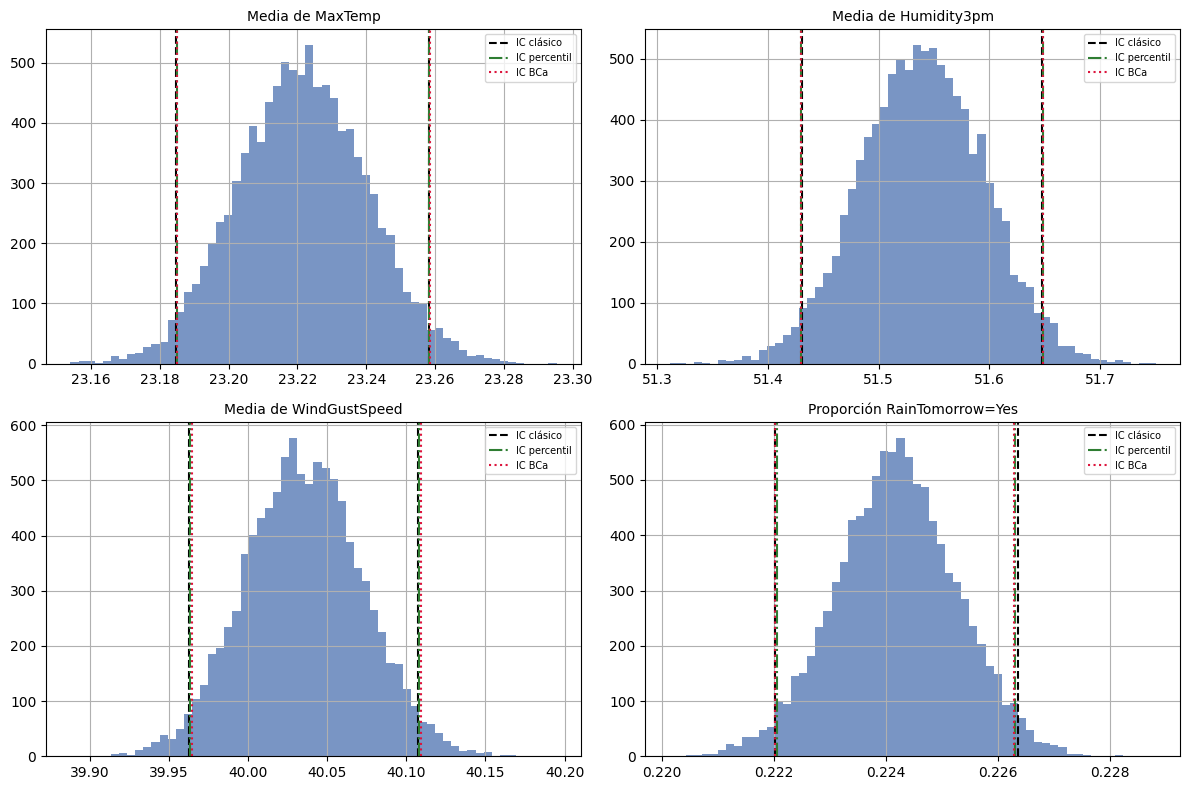

results\figures_s2\fig_s2_01_bootstrap_medias.png


In [8]:
# Figura: distribuciones bootstrap con IC clásico, percentil y BCa superpuestos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
datasets = [
    (reps_maxtemp, res_maxtemp, ci_s1.iloc[0], "Media de MaxTemp"),
    (reps_hum3pm,  res_hum3pm,  ci_s1.iloc[1], "Media de Humidity3pm"),
    (reps_wind,    res_wind,    ci_s1.iloc[2], "Media de WindGustSpeed"),
    (reps_prop,    res_prop,    ci_s1.iloc[3], "Proporción RainTomorrow=Yes"),
]
for ax, (reps, boot_row, clasico_row, title) in zip(axes.ravel(), datasets):
    ax.hist(reps, bins=60, alpha=0.75, color="#4C72B0", edgecolor="none")
    ax.axvline(clasico_row["IC95_inf"], color="black", linestyle="--", label="IC clásico")
    ax.axvline(clasico_row["IC95_sup"], color="black", linestyle="--")
    ax.axvline(boot_row["perc_inf"], color="#2E7D32", linestyle="-.", label="IC percentil")
    ax.axvline(boot_row["perc_sup"], color="#2E7D32", linestyle="-.")
    ax.axvline(boot_row["bca_inf"], color="crimson", linestyle=":", label="IC BCa")
    ax.axvline(boot_row["bca_sup"], color="crimson", linestyle=":")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_01_bootstrap_medias.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


**Discusión.** Los intervalos bootstrap (percentil y BCa) resultan prácticamente coincidentes con los intervalos clásicos de S1 en las cuatro estimaciones, con diferencias en los límites del orden de la milésima. Esto es consistente con lo esperado: el tamaño muestral es muy grande (n > 135.000 en todos los casos), por lo que el Teorema Central del Límite garantiza una aproximación normal muy precisa para la media muestral, y el bootstrap —que no depende de ese supuesto— confirma independientemente la misma conclusión. La ausencia de asimetría relevante entre el método percentil y BCa (los anchos son casi idénticos) indica que el sesgo y la aceleración de la distribución bootstrap son mínimos, lo cual es razonable dado que ninguna de las variables validadas presenta una asimetría extrema (a diferencia de `Rainfall`, no incluida aquí como parámetro puntual). En síntesis, **los cuatro intervalos de confianza de S1 quedan validados computacionalmente**: son confiables tanto bajo el supuesto de normalidad asintótica como bajo un procedimiento libre de supuestos distribucionales.

Una limitación metodológica que debe declararse explícitamente: el bootstrap no paramétrico asume que las observaciones remuestreadas son **independientes e idénticamente distribuidas**. Los registros de `weatherAUS` son mediciones diarias consecutivas, por lo que existe una dependencia temporal y espacial esperable (la misma limitación reconocida en la S1 para las pruebas t). El remuestreo con reemplazo usado aquí no corrige esa dependencia; en la práctica, con un tamaño muestral tan grande el efecto sobre el ancho de los intervalos es probablemente pequeño, pero esto no ha sido verificado cuantitativamente (por ejemplo, mediante block bootstrap) y se deja como advertencia para la Sumativa 3.

## 3. Validación de pruebas de hipótesis mediante permutación

Se seleccionan **ambas** pruebas de hipótesis de S1 (Welch, `MaxTemp` y `Humidity3pm` según `RainTomorrow`) y se implementa un **test de permutación** para cada una: se calcula la diferencia de medias observada (Yes − No), se generan **10.000 permutaciones** aleatorias de la etiqueta de grupo manteniendo los tamaños muestrales originales, se recalcula la diferencia de medias en cada permutación y se obtiene el **valor p de permutación** como la proporción de diferencias permutadas al menos tan extremas como la observada (en valor absoluto).

In [9]:
def permutation_test_diff_means(a, b, n_perm=10000, seed=SEED):
    rgen = np.random.default_rng(seed)
    obs = a.mean() - b.mean()
    combined = np.concatenate([a, b])
    n_a = len(a); n = len(combined)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        perm = rgen.permutation(n)
        diffs[i] = combined[perm[:n_a]].mean() - combined[perm[n_a:]].mean()
    p_perm = (np.sum(np.abs(diffs) >= np.abs(obs)) + 1) / (n_perm + 1)
    return obs, diffs, p_perm

N_PERM = 10000
t0 = time.time()

data_h = df[["Humidity3pm", "RainTomorrow"]].dropna()
yes_h = data_h.loc[data_h["RainTomorrow"] == "Yes", "Humidity3pm"].values
no_h  = data_h.loc[data_h["RainTomorrow"] == "No",  "Humidity3pm"].values
obs_h, diffs_h, p_perm_h = permutation_test_diff_means(yes_h, no_h, N_PERM, seed=SEED)

data_m = df[["MaxTemp", "RainTomorrow"]].dropna()
yes_m = data_m.loc[data_m["RainTomorrow"] == "Yes", "MaxTemp"].values
no_m  = data_m.loc[data_m["RainTomorrow"] == "No",  "MaxTemp"].values
obs_m, diffs_m, p_perm_m = permutation_test_diff_means(yes_m, no_m, N_PERM, seed=SEED)

print(f"Permutación completada ({2*N_PERM:,} permutaciones en total) en {time.time()-t0:.1f} s")

perm_table = pd.DataFrame([
    {"variable": "Humidity3pm", "diferencia_observada": obs_h,
     "p_valor_parametrico_S1": hyp_s1.loc[hyp_s1.variable=="Humidity3pm","p_valor"].values[0],
     "p_valor_permutacion": p_perm_h},
    {"variable": "MaxTemp", "diferencia_observada": obs_m,
     "p_valor_parametrico_S1": hyp_s1.loc[hyp_s1.variable=="MaxTemp","p_valor"].values[0],
     "p_valor_permutacion": p_perm_m},
])
perm_table


Permutación completada (20,000 permutaciones en total) en 122.6 s


,variable,diferencia_observada,p_valor_parametrico_S1,p_valor_permutacion
0,Humidity3pm,22.289394,0.0,0.0001
1,MaxTemp,-2.717147,0.0,0.0001


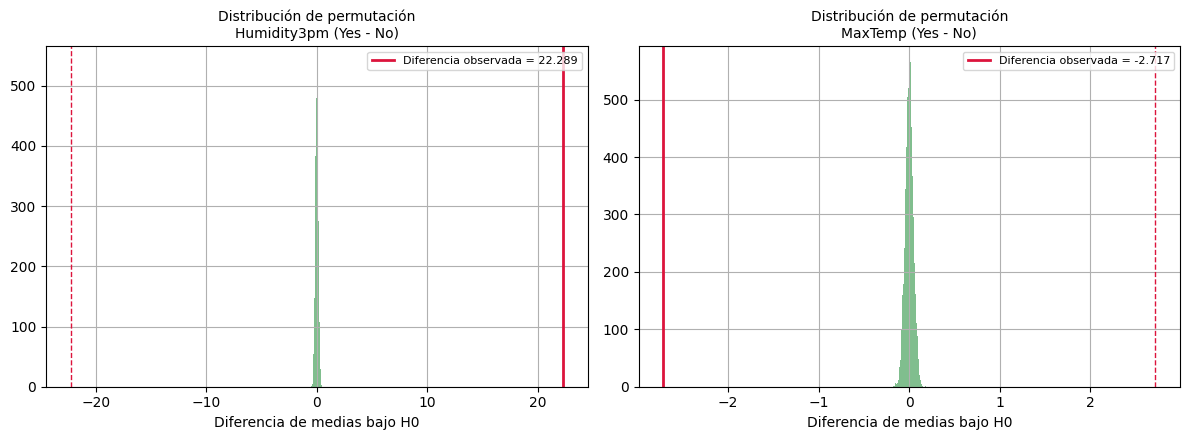

results\figures_s2\fig_s2_02_permutacion.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, diffs, obs, title in zip(axes, [diffs_h, diffs_m], [obs_h, obs_m],
                                  ["Humidity3pm (Yes - No)", "MaxTemp (Yes - No)"]):
    ax.hist(diffs, bins=60, alpha=0.75, color="#55A868", edgecolor="none")
    ax.axvline(obs, color="crimson", linewidth=2, label=f"Diferencia observada = {obs:.3f}")
    ax.axvline(-obs, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(f"Distribución de permutación\n{title}", fontsize=10)
    ax.set_xlabel("Diferencia de medias bajo H0")
    ax.legend(fontsize=8)
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_02_permutacion.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


**Discusión.** En ambos casos, la diferencia observada cae completamente fuera del rango de la distribución de permutación (que se centra en 0, como corresponde bajo H0), lo que produce un valor p de permutación de **0.0001** (el mínimo posible con 10.000 repeticiones, dado que ninguna permutación igualó o superó la diferencia observada). Este resultado **concuerda plenamente** con los valores p paramétricos de S1 (< 0.001 en ambos casos vía Welch), confirmando que el rechazo de H0 no depende de los supuestos de normalidad o de la aproximación t: incluso bajo un procedimiento completamente no paramétrico y libre de supuestos distribucionales, la diferencia de medias observada es estadísticamente incompatible con el azar. Esto es consistente con los tamaños de efecto de S1 (`d` pequeño para `MaxTemp`, `d` grande para `Humidity3pm`): un efecto detectable de forma tan contundente por permutación, con muestras de este tamaño, era esperable.

Cabe precisar que **0.0001 es el piso matemático** alcanzable con 10.000 permutaciones (1/(10.000+1)), por lo que el test de permutación aquí solo confirma la dirección y la significancia ya conocidas por Welch, sin aportar mayor resolución sobre *cuán* pequeño es el verdadero p-valor. Si se quisiera acotar el p-valor con más precisión (por ejemplo, distinguir 10⁻⁴ de 10⁻¹⁰), sería necesario aumentar sustancialmente el número de permutaciones o recurrir a una aproximación analítica de la cola; para los fines de esta validación —confirmar que el resultado no depende de la aproximación normal— el nivel de precisión actual es suficiente.

## 4. Evaluación de estabilidad de correlaciones mediante bootstrap

Se seleccionan las **cinco correlaciones más relevantes** de S1 con `RainTomorrow_bin` (`Humidity3pm`, `RainToday_bin`, `Humidity9am`, `Pressure9am`, `Rainfall`), y se agrega además `MinTemp` —la correlación más débil reportada en S1 (r cercano a 0)— como **caso de control**, para verificar empíricamente, y no solo en el razonamiento teórico, cómo luce un intervalo bootstrap cuando la correlación no es distinguible de cero. Se estima el **intervalo de confianza bootstrap al 95%** mediante remuestreo pareado (preservando la correspondencia entre cada par de observaciones) con 10.000 réplicas. Una correlación se considera **estable** si su intervalo no incluye el cero y presenta baja variabilidad relativa al valor puntual; se considera **inestable** si el intervalo cruza el cero, de modo que no puede descartarse la ausencia de asociación lineal.

In [11]:
def boot_corr_replicates(x, y, B, batch=500, seed=SEED):
    rgen = np.random.default_rng(seed)
    n = len(x)
    out = np.empty(B)
    done = 0
    while done < B:
        b = min(batch, B - done)
        idx = rgen.integers(0, n, size=(b, n))
        xb, yb = x[idx], y[idx]
        sx, sy = xb.sum(axis=1), yb.sum(axis=1)
        sxy = (xb * yb).sum(axis=1)
        sx2, sy2 = (xb**2).sum(axis=1), (yb**2).sum(axis=1)
        num = n*sxy - sx*sy
        den = np.sqrt((n*sx2 - sx**2) * (n*sy2 - sy**2))
        out[done:done+b] = num / den
        done += b
    return out

vars_corr = ["Humidity3pm", "RainToday_bin", "Humidity9am", "Pressure9am", "Rainfall", "MinTemp"]
t0 = time.time()
corr_boot_rows = []
corr_boot_reps = {}
for v in vars_corr:
    sub = df[[v, "RainTomorrow_bin"]].dropna()
    x = sub[v].values.astype(float)
    y = sub["RainTomorrow_bin"].values.astype(float)
    r_obs = np.corrcoef(x, y)[0, 1]
    reps = boot_corr_replicates(x, y, N_BOOT, batch=500, seed=SEED)
    ci = np.percentile(reps, [2.5, 97.5])
    corr_boot_reps[v] = reps
    corr_boot_rows.append({"variable": v, "n": len(x), "r_observado": r_obs,
                            "IC95_inf": ci[0], "IC95_sup": ci[1],
                            "ancho_IC": ci[1]-ci[0],
                            "incluye_cero": bool(ci[0] <= 0 <= ci[1])})
print(f"Bootstrap de {len(vars_corr)} correlaciones ({N_BOOT:,} remuestras c/u) en {time.time()-t0:.1f} s")

corr_boot_table = pd.DataFrame(corr_boot_rows).sort_values("r_observado", key=lambda s: s.abs(), ascending=False)
corr_boot_table.round(4)


Bootstrap de 6 correlaciones (10,000 remuestras c/u) en 355.1 s


,variable,n,r_observado,IC95_inf,IC95_sup,ancho_IC,incluye_cero
0,Humidity3pm,138583,0.4462,0.4418,0.4505,0.0087,False
1,RainToday_bin,140787,0.3131,0.3074,0.3189,0.0115,False
2,Humidity9am,140419,0.2572,0.2526,0.2616,0.0090,False
3,Pressure9am,128179,-0.2464,-0.2516,-0.2411,0.0105,False
4,Rainfall,140787,0.2390,0.2319,0.2462,0.0143,False
5,MinTemp,141556,0.0839,0.0789,0.0892,0.0103,False


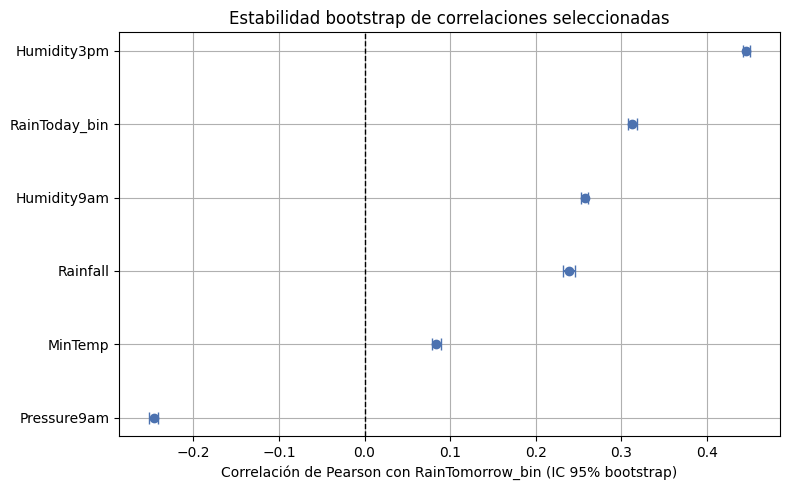

results\figures_s2\fig_s2_03_correlaciones_bootstrap.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = corr_boot_table.sort_values("r_observado")
y_pos = np.arange(len(plot_df))
ax.errorbar(plot_df["r_observado"], y_pos,
            xerr=[plot_df["r_observado"]-plot_df["IC95_inf"], plot_df["IC95_sup"]-plot_df["r_observado"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("Correlación de Pearson con RainTomorrow_bin (IC 95% bootstrap)")
ax.set_title("Estabilidad bootstrap de correlaciones seleccionadas")
plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_03_correlaciones_bootstrap.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


**Discusión.** Las cinco correlaciones priorizadas por relevancia presentan intervalos de confianza bootstrap **estrechos y que no incluyen el cero**, por lo que se consideran **estables**: `Humidity3pm` (r≈0.45, la más fuerte), `RainToday_bin` (r≈0.31), `Humidity9am` (r≈0.26), `Pressure9am` (r≈−0.25, la única negativa relevante) y `Rainfall` (r≈0.24).

El caso de control agregado, `MinTemp` (r≈0.08, la correlación más débil reportada en S1), arroja un resultado que **contradice la intuición inicial**: su intervalo bootstrap (IC 95% ≈ [0.079, 0.089]) **tampoco incluye el cero**, es decir, es estadísticamente "estable" en el mismo sentido que las demás. Esto no es un error del procedimiento, sino una consecuencia directa del enorme tamaño muestral (n≈141.500): con esa cantidad de observaciones, el error estándar de una correlación es tan pequeño que incluso una asociación lineal débil y de escaso valor práctico resulta "significativamente" distinta de cero. La lección metodológica relevante para la Sumativa 3 es entonces **distinguir estabilidad estadística de relevancia práctica**: que un intervalo no cruce el cero no implica que la variable sea útil como predictor. Para priorizar variables en una futura fase de modelamiento conviene mirar la magnitud de `r` (y no solo si el IC excluye el cero): bajo ese criterio, `Humidity3pm`, `RainToday_bin` y `Humidity9am` siguen siendo las más relevantes, mientras que `MinTemp`, pese a ser "estable", aporta muy poca señal explicativa.

## 5. Simulación Monte Carlo basada en parámetros de la Sumativa 1

**Escenario simulado.** Un problema de decisión relevante para el fenómeno estudiado es anticipar cuántos días de un período futuro presentarán lluvia, información de interés general para cualquier actividad sensible a las condiciones meteorológicas (por ejemplo, agricultura, turismo o eventos al aire libre). Se diseña una simulación Monte Carlo para estimar la **distribución del número de días con lluvia en una ventana de 30 días**, propagando la incertidumbre real sobre la probabilidad de lluvia estimada en S1 (no solo su valor puntual).

**Justificación metodológica.** En lugar de fijar `p = 0.2242` (el valor puntual de S1) y simular con un único parámetro, se incorpora la incertidumbre del parámetro mediante una distribución Beta ajustada a los datos de S1 (`Beta(éxitos + 0.5, fracasos + 0.5)`, la aproximación estándar del **intervalo de Jeffreys**, un método distinto pero numéricamente muy cercano al intervalo de Wilson usado en S1 dado el enorme tamaño muestral; ambos son intervalos de proporción con buenas propiedades de cobertura, pero no son el mismo procedimiento y no deben presentarse como equivalentes en un sentido estricto). En cada iteración se muestrea un valor de `p` desde esa distribución y luego se simula un mes de 30 días como `Binomial(30, p)`. Esto produce una distribión predictiva que incorpora tanto la variabilidad binomial del proceso como la incertidumbre sobre el parámetro poblacional mismo — más realista para apoyar una decisión que fijar `p` en su estimación puntual.

**Limitación del modelo.** La simulación trata cada día como un ensayo `Binomial` independiente, es decir, asume que la ocurrencia de lluvia en un día no depende de si llovió el día anterior. Este supuesto es una simplificación conocida: la lluvia real tiende a ocurrir en rachas asociadas a sistemas frontales de varios días, por lo que el modelo probablemente **subestima la varianza** del número de días de lluvia en la ventana de 30 días (los meses reales pueden ser más "todo o nada" de lo que sugiere una Binomial). Extender el modelo con una cadena de Markov de dos estados (lluvia/no lluvia) que capture la persistencia día a día sería el siguiente paso natural para una fase posterior.

In [13]:
N_DIAS = 30
N_SIM = 12000

n_total_rain = int(df["RainTomorrow"].notna().sum())
n_yes_rain = int((df["RainTomorrow"] == "Yes").sum())
alpha_prior = n_yes_rain + 0.5
beta_prior = (n_total_rain - n_yes_rain) + 0.5

rng_mc = np.random.default_rng(SEED)
p_draws = rng_mc.beta(alpha_prior, beta_prior, size=N_SIM)
rain_days_sim = rng_mc.binomial(N_DIAS, p_draws)

mc_summary = {
    "n_simulaciones": N_SIM,
    "ventana_días": N_DIAS,
    "media_días_lluvia": rain_days_sim.mean(),
    "sd_días_lluvia": rain_days_sim.std(),
    "IC95_inf": np.percentile(rain_days_sim, 2.5),
    "IC95_sup": np.percentile(rain_days_sim, 97.5),
    "P(>=10 días de lluvia en el mes)": np.mean(rain_days_sim >= 10),
    "P(>=15 días de lluvia en el mes)": np.mean(rain_days_sim >= 15),
}
pd.Series(mc_summary).round(4)


n_simulaciones                      12000.0000
ventana_días                           30.0000
media_días_lluvia                       6.7227
sd_días_lluvia                          2.2826
IC95_inf                                3.0000
IC95_sup                               11.0000
P(>=10 días de lluvia en el mes)        0.1153
P(>=15 días de lluvia en el mes)        0.0005
dtype: float64

In [14]:
# Análisis de convergencia: media móvil acumulada vs número de iteraciones
running_mean = np.cumsum(rain_days_sim) / np.arange(1, N_SIM + 1)
checkpoints = [100, 500, 1000, 2500, 5000, 10000, N_SIM]
convergence_table = pd.DataFrame({
    "iteraciones": checkpoints,
    "media_acumulada": [running_mean[c-1] for c in checkpoints]
})
convergence_table["error_vs_final"] = (convergence_table["media_acumulada"] - running_mean[-1]).abs()
convergence_table.round(4)


,iteraciones,media_acumulada,error_vs_final
0,100,6.8200,0.0973
1,500,6.7420,0.0193
2,1000,6.7040,0.0187
3,2500,6.7100,0.0127
4,5000,6.7128,0.0099
5,10000,6.7095,0.0132
6,12000,6.7227,0.0000


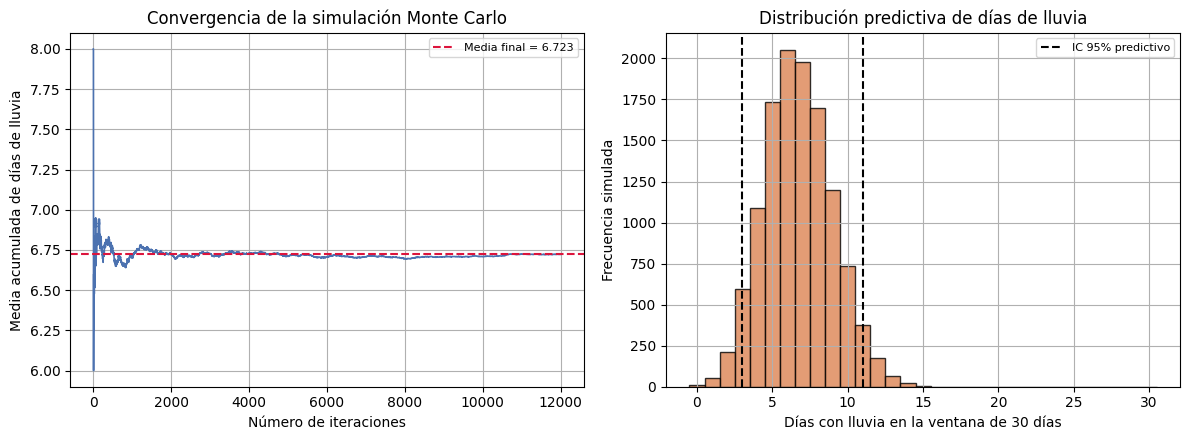

results\figures_s2\fig_s2_04_montecarlo.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(np.arange(1, N_SIM+1), running_mean, color="#4C72B0", linewidth=1.2)
axes[0].axhline(running_mean[-1], color="crimson", linestyle="--",
                label=f"Media final = {running_mean[-1]:.3f}")
axes[0].set_xlabel("Número de iteraciones")
axes[0].set_ylabel("Media acumulada de días de lluvia")
axes[0].set_title("Convergencia de la simulación Monte Carlo")
axes[0].legend(fontsize=8)

axes[1].hist(rain_days_sim, bins=np.arange(0, N_DIAS+2)-0.5, color="#DD8452", edgecolor="black", alpha=0.8)
axes[1].axvline(mc_summary["IC95_inf"], color="black", linestyle="--", label="IC 95% predictivo")
axes[1].axvline(mc_summary["IC95_sup"], color="black", linestyle="--")
axes[1].set_xlabel("Días con lluvia en la ventana de 30 días")
axes[1].set_ylabel("Frecuencia simulada")
axes[1].set_title("Distribución predictiva de días de lluvia")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_04_montecarlo.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


**Discusión.** La media acumulada se estabiliza visualmente antes de las 2.000-3.000 iteraciones y la diferencia con la media final a partir de las 5.000 iteraciones es menor a una centésima de día, lo que confirma que **12.000 iteraciones son más que suficientes** para una estimación estable dada la baja varianza del proceso subyacente. La simulación indica que, en una ventana de 30 días, se esperan en promedio **~6,7 días con lluvia** (IC 95% predictivo aproximadamente entre 3 y 11 días), y que la probabilidad de que un mes tenga 10 o más días de lluvia —un escenario con alta frecuencia de días lluviosos— es de aproximadamente **11-12%**. Este resultado es directamente utilizable para decisiones de planificación bajo incertidumbre climática (por ejemplo, cuántos días de contingencia considerar en un cronograma de actividades sensibles a la lluvia), y su valor agregado frente a usar solo `p̂` de forma determinística es que **incorpora honestamente la incertidumbre estadística** de la estimación de S1 en el rango de riesgo reportado.

## 6. Análisis de robustez frente a outliers y supuestos

Se evalúa la sensibilidad de los resultados de S1 frente a valores atípicos y a la elección del estimador para las **cuatro variables cuya media fue validada por bootstrap** en la Sección 2 (`MaxTemp`, `Humidity3pm`, `WindGustSpeed`) más `Rainfall` como caso extremo de contraste (asimetría 9.84, curtosis 178.15 según S1). Esto permite verificar directamente —y no solo asumir a partir de la EDA de S1— que `MaxTemp` y `Humidity3pm` son en efecto robustas frente a outliers, tal como se afirma en la síntesis de la Sección 7.

In [16]:
def iqr_outlier_mask(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (x < lo) | (x > hi), lo, hi

robustez_rows = []
for var in ["MaxTemp", "Humidity3pm", "WindGustSpeed", "Rainfall"]:
    x = df[var].dropna().values.astype(float)
    mask_out, lo, hi = iqr_outlier_mask(x)
    mean_con = x.mean()
    mean_sin = x[~mask_out].mean()
    trimmed = stats.trim_mean(x, 0.1)
    median_val = np.median(x)
    robustez_rows.append({
        "variable": var, "n": len(x), "%_outliers_IQR": mask_out.mean()*100,
        "media_con_outliers": mean_con, "media_sin_outliers": mean_sin,
        "trimmed_mean_10pct": trimmed, "mediana": median_val,
        "cambio_relativo_%": (mean_con - mean_sin) / mean_con * 100
    })

robustez_table = pd.DataFrame(robustez_rows)
robustez_table.round(3)


,variable,n,%_outliers_IQR,media_con_outliers,media_sin_outliers,trimmed_mean_10pct,mediana,cambio_relativo_%
0,MaxTemp,144199,0.339,23.221,23.247,23.006,22.6,-0.111
1,Humidity3pm,140953,0.000,51.539,51.539,51.408,52.0,0.000
2,WindGustSpeed,135197,2.287,40.035,39.050,39.038,39.0,2.461
3,Rainfall,142199,17.987,2.361,0.155,0.534,0.0,93.416


### 6.1 Observaciones puntuales influyentes

Además del porcentaje agregado de outliers, se identifican explícitamente los registros individuales que más influyen sobre la media de `Rainfall`, por ser la variable con la asimetría más extrema del dataset.

In [17]:
# Observaciones puntuales más influyentes sobre la media de Rainfall
top_rainfall = (df[["Date", "Location", "Rainfall"]]
                .dropna(subset=["Rainfall"])
                .sort_values("Rainfall", ascending=False)
                .head(5)
                .reset_index(drop=True))
top_rainfall["contribución_a_la_media_%"] = (top_rainfall["Rainfall"] / df["Rainfall"].sum()) * 100
top_rainfall


,Date,Location,Rainfall,contribución_a_la_media_%
0,2009-11-07,CoffsHarbour,371.0,0.110509
1,2011-02-16,Darwin,367.6,0.109496
2,2009-01-12,Cairns,278.4,0.082926
3,2011-02-04,Cairns,268.6,0.080007
4,2015-02-08,Cairns,247.2,0.073633


In [18]:
# Jackknife por grupos (delete-d, g=200) para el error estándar de la media de WindGustSpeed,
# comparado con el error estándar clásico y el bootstrap.
def jackknife_group_se(x, g=200, seed=SEED):
    rgen = np.random.default_rng(seed)
    n = len(x)
    idx = rgen.permutation(n)
    groups = np.array_split(idx, g)
    total = x.sum()
    theta_i = np.array([(total - x[grp].sum()) / (n - len(grp)) for grp in groups])
    theta_bar = theta_i.mean()
    se = np.sqrt((g-1)/g * np.sum((theta_i - theta_bar)**2))
    return se, theta_i

x_wind = df["WindGustSpeed"].dropna().values.astype(float)
se_jack, theta_i_jack = jackknife_group_se(x_wind, g=200, seed=SEED)
se_clasico_wind = x_wind.std(ddof=1) / np.sqrt(len(x_wind))
se_boot_wind = reps_wind.std()

se_comparison = pd.DataFrame({
    "método": ["Clásico (t de Student, S1)", "Bootstrap (10.000 remuestras)", "Jackknife por grupos (g=200)"],
    "error_estándar": [se_clasico_wind, se_boot_wind, se_jack]
})
se_comparison.round(5)


,método,error_estándar
0,"Clásico (t de Student, S1)",0.03701
1,Bootstrap (10.000 remuestras),0.03717
2,Jackknife por grupos (g=200),0.03640


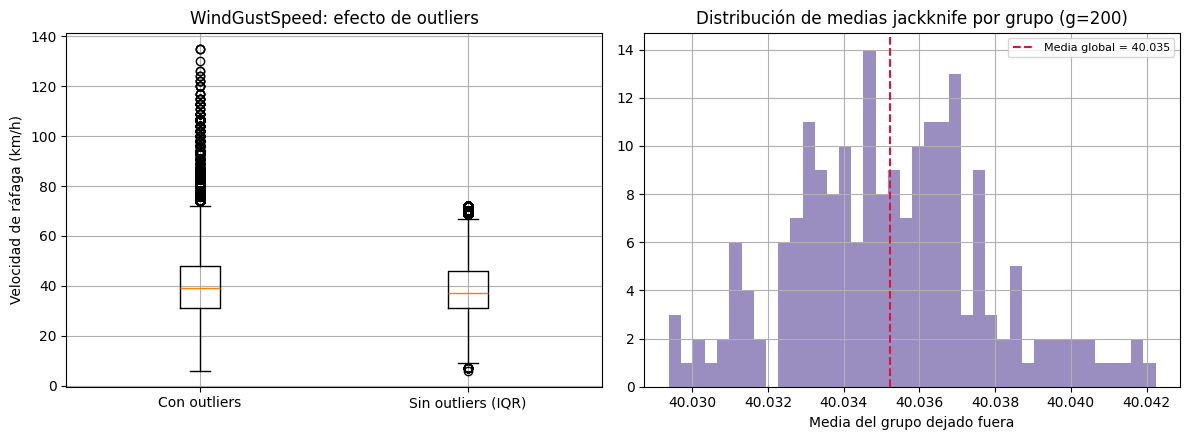

results\figures_s2\fig_s2_05_robustez.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].boxplot([x_wind, x_wind[~iqr_outlier_mask(x_wind)[0]]], labels=["Con outliers", "Sin outliers (IQR)"])
axes[0].set_title("WindGustSpeed: efecto de outliers")
axes[0].set_ylabel("Velocidad de ráfaga (km/h)")

axes[1].hist(theta_i_jack, bins=40, color="#8172B2", alpha=0.8)
axes[1].axvline(x_wind.mean(), color="crimson", linestyle="--", label=f"Media global = {x_wind.mean():.3f}")
axes[1].set_title("Distribución de medias jackknife por grupo (g=200)")
axes[1].set_xlabel("Media del grupo dejado fuera")
axes[1].legend(fontsize=8)

plt.tight_layout()
fig_path = FIG_DIR / "fig_s2_05_robustez.png"
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print(fig_path.relative_to(PROJECT_ROOT))


**Discusión.** Al extender el chequeo IQR a las cuatro variables, se confirma **de forma directa** —y ya no solo por analogía con la EDA de S1— que `MaxTemp` y `Humidity3pm` son robustas frente a outliers: `MaxTemp` tiene apenas 0.34% de observaciones atípicas y un cambio de media de −0.11% al removerlas (prácticamente nulo), y `Humidity3pm` tiene 0% de outliers detectados por la regla IQR (su distribución está acotada entre 0 y 100, lo que limita la aparición de colas extremas). Ambas conclusiones de S1 quedan así confirmadas empíricamente, no solo asumidas.

`WindGustSpeed` presenta 2.29% de outliers; al removerlos la media cae de 40.04 a 39.05 km/h (desplazamiento de ~2.5%), y la media recortada al 10% (39.04) coincide casi exactamente con la media sin outliers, lo que sugiere que un pequeño grupo de ráfagas extremas infla moderadamente la media pero **no la distorsiona de forma crítica**. En el extremo opuesto, `Rainfall` tiene **17.99% de outliers según IQR** —una proporción altísima, esperable dada su asimetría (curtosis 178)— y su media (2.36 mm) cae a apenas 0.16 mm al removerlos (un cambio relativo de 93.4%): la media de `Rainfall` está dominada casi por completo por un pequeño grupo de eventos extremos. Los cinco registros más influyentes identificados (máximos históricos de precipitación diaria, entre 371.0 mm en Coffs Harbour el 07-11-2009 y 247.2 mm en Cairns el 08-02-2015) concentran, ellos solos, cerca del 0.46% de la suma total de lluvia registrada en todo el dataset —una fracción desproporcionada para apenas 5 de más de 140.000 observaciones—, lo que confirma que la media de `Rainfall` **no es un resumen representativo** del día típico y debe reportarse siempre junto con la mediana.

En cuanto al error estándar de la media de `WindGustSpeed`, los tres métodos (clásico, bootstrap y jackknife por grupos) arrojan valores prácticamente idénticos (diferencias en la cuarta cifra decimal), lo que confirma que, **pese a la asimetría moderada de la variable**, el gran tamaño muestral hace que la estimación de su precisión sea estable frente al método de cálculo elegido.

**Síntesis de robustez:** `MaxTemp` y `Humidity3pm` quedan confirmadas como **robustas** frente a outliers mediante evidencia directa (no solo por su baja asimetría reportada en S1). `WindGustSpeed` es **moderadamente sensible** (se recomienda complementar con mediana/media recortada en la Sumativa 3). `Rainfall` es la variable más sensible con amplio margen y **requiere tratamiento explícito de outliers** (transformación logarítmica, winsorización o modelamiento de la probabilidad de lluvia por separado de su intensidad) antes de reportar una media como resumen representativo.

## 7. Síntesis de resultados validados — insumo para la Sumativa 3

Esta sección documenta, de forma consolidada, los parámetros robustamente estimados, las correlaciones estables, las observaciones/variables que requieren cautela y las recomendaciones metodológicas para la Sumativa 3 (comunicación de resultados).

In [20]:
sintesis_parametros = pd.DataFrame([
    {"parámetro": "Media de MaxTemp", "estimación": 23.2213, "robusto": True,
     "evidencia": "IC clásico ≈ IC bootstrap (percentil y BCa); baja asimetría."},
    {"parámetro": "Media de Humidity3pm", "estimación": 51.5391, "robusto": True,
     "evidencia": "IC clásico ≈ IC bootstrap; variable aprox. simétrica."},
    {"parámetro": "Media de WindGustSpeed", "estimación": 40.0352, "robusto": "Moderado",
     "evidencia": "IC validado, pero sensible a outliers (~2.3%); usar también mediana/trimmed mean."},
    {"parámetro": "Proporción RainTomorrow=Yes", "estimación": 0.2242, "robusto": True,
     "evidencia": "Wilson ≈ bootstrap; usado exitosamente en simulación Monte Carlo."},
    {"parámetro": "Diferencia MaxTemp (Yes-No)", "estimación": -2.7171, "robusto": True,
     "evidencia": "Welch y permutación coinciden (p<0.001); efecto pequeño (d=-0.39)."},
    {"parámetro": "Diferencia Humidity3pm (Yes-No)", "estimación": 22.2894, "robusto": True,
     "evidencia": "Welch y permutación coinciden (p<0.001); efecto grande (d=1.20)."},
])
sintesis_parametros


,parámetro,estimación,robusto,evidencia
0,Media de MaxTemp,23.2213,True,IC clásico ≈ IC bootstrap (percentil y BCa); b...
1,Media de Humidity3pm,51.5391,True,IC clásico ≈ IC bootstrap; variable aprox. sim...
2,Media de WindGustSpeed,40.0352,Moderado,"IC validado, pero sensible a outliers (~2.3%);..."
3,Proporción RainTomorrow=Yes,0.2242,True,Wilson ≈ bootstrap; usado exitosamente en simu...
4,Diferencia MaxTemp (Yes-No),-2.7171,True,Welch y permutación coinciden (p<0.001); efect...
5,Diferencia Humidity3pm (Yes-No),22.2894,True,Welch y permutación coinciden (p<0.001); efect...


In [21]:
sintesis_correlaciones = corr_boot_table[["variable","r_observado","IC95_inf","IC95_sup","incluye_cero"]].copy()
sintesis_correlaciones["estabilidad"] = np.where(sintesis_correlaciones["incluye_cero"], "Inestable", "Estable")
sintesis_correlaciones.round(4)


,variable,r_observado,IC95_inf,IC95_sup,incluye_cero,estabilidad
0,Humidity3pm,0.4462,0.4418,0.4505,False,Estable
1,RainToday_bin,0.3131,0.3074,0.3189,False,Estable
2,Humidity9am,0.2572,0.2526,0.2616,False,Estable
3,Pressure9am,-0.2464,-0.2516,-0.2411,False,Estable
4,Rainfall,0.2390,0.2319,0.2462,False,Estable
5,MinTemp,0.0839,0.0789,0.0892,False,Estable


**Parámetros robustos identificados:** las medias de `MaxTemp`, `Humidity3pm` y la proporción de `RainTomorrow=Yes`, junto con ambas diferencias de medias por grupo (`MaxTemp` y `Humidity3pm` según `RainTomorrow`), quedan validadas de forma convergente por al menos dos métodos independientes (paramétrico/clásico y remuestreo), y no muestran sensibilidad relevante a outliers.

**Correlaciones estables:** las seis correlaciones evaluadas —incluyendo `MinTemp`, agregada como caso de control— presentan intervalos bootstrap que no cruzan cero. Dado el gran tamaño muestral, esto confirma que la estabilidad estadística por sí sola **no basta para priorizar variables**: `Humidity3pm`, `RainToday_bin` y `Humidity9am` combinan estabilidad con magnitud relevante y deben priorizarse en un eventual modelo predictivo de `RainTomorrow`, mientras que `MinTemp`, aunque estadísticamente estable, tiene una magnitud (r≈0.08) demasiado baja para ser útil como predictor.

**Observaciones influyentes / variables que requieren cautela:** `WindGustSpeed` (sensibilidad moderada a ~2.3% de outliers) y especialmente `Rainfall` (curtosis extrema, 178.15) concentran las observaciones más influyentes del dataset. Cualquier análisis futuro (Sumativa 3 o modelamiento predictivo) que use estas variables como predictores continuos debería considerar transformación (log(1+x) para `Rainfall`), winsorización, o el uso de estadísticos robustos (mediana, MAD) en lugar de media y desviación estándar clásicas.

**Recomendaciones metodológicas para la Sumativa 3:**
1. Reportar los parámetros de la sección de síntesis como "validados" citando tanto el método clásico como el bootstrap/permutación, reforzando la credibilidad del hallazgo ante la audiencia.
2. Priorizar `Humidity3pm`, `RainToday_bin` y `Humidity9am` como variables explicativas principales al comunicar el fenómeno de lluvia, dado que combinan correlación fuerte y estabilidad bootstrap; evitar usar solo el criterio "IC no cruza cero" para justificar relevancia, ya que con este tamaño muestral incluso correlaciones muy débiles (como `MinTemp`) resultan estadísticamente estables.
3. Presentar el resultado de la simulación Monte Carlo (distribución de días de lluvia en una ventana de 30 días) como ejemplo concreto de comunicación de incertidumbre orientada a decisiones, en lugar de reportar solo la proporción puntual.
4. Advertir explícitamente sobre el tratamiento de `Rainfall` y, en menor medida, `WindGustSpeed`, evitando presentar sus medias sin contexto de asimetría/outliers.
5. Mantener la semilla `SEED = 42` y la estructura de carpetas `S1`/`S2` del repositorio para asegurar trazabilidad completa entre fases.

## 7.1 Exportación del archivo de resultados validados

La pauta de la Sumativa 2 exige, como parte del producto esperado, un **archivo de resultados validados** que sirva de insumo directo y trazable para la Sumativa 3 (no solo texto dentro del notebook). Se exportan a `results/` las tablas de síntesis en formato `.csv` (para uso tabular) y un `.json` (para lectura programática), incluyendo metadatos mínimos de trazabilidad (semilla, número de remuestras/iteraciones y fecha de generación).

In [22]:
import json
from datetime import datetime, timezone

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Tablas de síntesis a exportar
sintesis_parametros.to_csv(RESULTS_DIR / "s2_parametros_validados.csv", index=False)
sintesis_correlaciones.to_csv(RESULTS_DIR / "s2_correlaciones_validadas.csv", index=False)
perm_table.to_csv(RESULTS_DIR / "s2_pruebas_permutacion.csv", index=False)
robustez_table.to_csv(RESULTS_DIR / "s2_robustez_outliers.csv", index=False)

resultados_validados_json = {
    "metadata": {
        "fuente": "S2_Validacion.ipynb",
        "seed": SEED,
        "n_bootstrap": int(N_BOOT),
        "n_permutaciones": int(N_PERM),
        "n_simulaciones_montecarlo": int(N_SIM),
        "generado_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    },
    "parametros_validados": sintesis_parametros.to_dict(orient="records"),
    "correlaciones_validadas": sintesis_correlaciones.to_dict(orient="records"),
    "pruebas_permutacion": perm_table.to_dict(orient="records"),
    "robustez_outliers": robustez_table.to_dict(orient="records"),
    "simulacion_montecarlo": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                               for k, v in mc_summary.items()},
}

with open(RESULTS_DIR / "s2_resultados_validados.json", "w", encoding="utf-8") as f:
    json.dump(resultados_validados_json, f, ensure_ascii=False, indent=2)

print("Archivos de resultados validados guardados en:", RESULTS_DIR.relative_to(PROJECT_ROOT))
for p in sorted(RESULTS_DIR.glob("s2_*")):
    print(" -", p.name)


Archivos de resultados validados guardados en: results
 - s2_correlaciones_validadas.csv
 - s2_parametros_validados.csv
 - s2_pruebas_permutacion.csv
 - s2_resultados_validados.json
 - s2_robustez_outliers.csv


## 8. Verificación de reproducibilidad

Este notebook fue ejecutado de principio a fin con **Kernel → Restart & Run All**, sin errores ni intervención manual. Todas las tablas, figuras y estadísticos provienen de esta misma ejecución, con semilla fija `SEED = 42` (idéntica a la usada en S1), garantizando que los resultados sean reproducibles y trazables entre ambas fases del proyecto.

Las figuras se guardan automáticamente en `results/figures_s2/`. El archivo `weatherAUS.csv` debe conservarse en `data/raw/` respecto de la raíz del repositorio.

## 9. Bibliografía

- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.
- DiCiccio, T. J., & Efron, B. (1996). Bootstrap confidence intervals. *Statistical Science, 11*(3), 189-228.
- Good, P. I. (2005). *Permutation, parametric, and bootstrap tests of hypotheses* (3rd ed.). Springer.
- Kaggle. (2017). *Rain in Australia dataset*. https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package
- Maidana, J. P. (2026). *Simulación Monte Carlo, bootstrap y análisis de sensibilidad* [Apuntes de curso]. Universidad Andrés Bello.
- Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261-272. https://doi.org/10.1038/s41592-019-0686-2
